# Modeling dataset sturktur protein 1 Dimensi dengan labeling baseline Q3 (Helix, Sheet, Coil)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np

base_dir = "/content/drive/MyDrive/Dataset Protein"

cb513 = np.load(base_dir + "/cb513+profile_split1.npy.gz", allow_pickle=True)
cullpdb = np.load(base_dir + "/cullpdb+profile_5926_filtered.npy.gz", allow_pickle=True)

# reshape
cb513 = cb513.reshape(cb513.shape[0], 700, 57)
cullpdb = cullpdb.reshape(cullpdb.shape[0], 700, 57)

print(cb513.shape)
print(cullpdb.shape)

/tmp/ipykernel_6237/119562786.py:5: UserWarning: Reading `.npy` or `.npz` file required additional header parsing as it was created on Python 2. Save the file again to speed up loading and avoid this warning.
  cb513 = np.load(base_dir + "/cb513+profile_split1.npy.gz", allow_pickle=True)


(514, 700, 57)
(5365, 700, 57)


In [ ]:
#Split data
np.random.seed(42)

n_samples = cullpdb.shape[0]
indices = np.random.permutation(n_samples)

split = int(0.8 * n_samples)

train_idx = indices[:split]
val_idx   = indices[split:]

dataset_train = cullpdb[train_idx]
dataset_val   = cullpdb[val_idx]
dataset_test  = cb513

In [ ]:
def extract(dataset):
    y = dataset[:, :, 21:24] #Q3

    #fitur
    X_aa = dataset[:, :, :21]
    X_other = dataset[:, :, 24:]
    X = np.concatenate([X_aa, X_other], axis=2)

    #mask
    mask = np.sum(X, axis=2) != 0

    return X.astype(np.float32), y.astype(np.float32), mask

#Apply dataset
X_train, y_train, mask_train = extract(dataset_train)
X_val,   y_val,   mask_val   = extract(dataset_val)
X_test,  y_test,  mask_test  = extract(dataset_test)

In [ ]:
#Modeling
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, Dropout, TimeDistributed, Dense

input_layer = Input(shape=(700, 54))

x = Conv1D(64, 3, padding='same', activation='relu')(input_layer)
x = Conv1D(128, 3, padding='same', activation='relu')(x)

x = Dropout(0.3)(x)

x = TimeDistributed(Dense(64, activation='relu'))(x)
output = TimeDistributed(Dense(3, activation='softmax'))(x)

model = Model(inputs=input_layer, outputs=output)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 700, 54)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 700, 64)        │        10,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 700, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 700, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 700, 64)        │         8,256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 700, 3)         │           195 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,587 (170.26 KB)

 Trainable params: 43,587 (170.26 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#Callback
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

In [ ]:
history = model.fit(
    X_train, y_train,
    sample_weight=mask_train.astype(float),
    validation_data=(X_val, y_val, mask_val.astype(float)),
    epochs=30,
    batch_size=16,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7336 - loss: 0.1308  

269/269 ━━━━━━━━━━━━━━━━━━━━ 1058s 2s/step - accuracy: 0.7494 - loss: 0.0408 - val_accuracy: 0.7506 - val_loss: 0.0108
Epoch 2/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 18s 67ms/step - accuracy: 0.7517 - loss: 0.0108 - val_accuracy: 0.7506 - val_loss: 0.0106
Epoch 3/30
268/269 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7525 - loss: 0.0104

269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step - accuracy: 0.7517 - loss: 0.0105 - val_accuracy: 0.7506 - val_loss: 0.0102
Epoch 4/30
268/269 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7546 - loss: 0.0099

269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 65ms/step - accuracy: 0.7517 - loss: 0.0103 - val_accuracy: 0.7507 - val_loss: 0.0101
Epoch 5/30
268/269 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7560 - loss: 0.0099

269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 65ms/step - accuracy: 0.7518 - loss: 0.0100 - val_accuracy: 0.7507 - val_loss: 0.0102
Epoch 6/30
268/269 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7552 - loss: 0.0096

269/269 ━━━━━━━━━━━━━━━━━━━━ 18s 65ms/step - accuracy: 0.7518 - loss: 0.0098 - val_accuracy: 0.7507 - val_loss: 0.0100
Epoch 7/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step - accuracy: 0.7518 - loss: 0.0097 - val_accuracy: 0.7507 - val_loss: 0.0099
Epoch 8/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step - accuracy: 0.7519 - loss: 0.0095 - val_accuracy: 0.7507 - val_loss: 0.0098
Epoch 9/30
268/269 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7517 - loss: 0.0094

269/269 ━━━━━━━━━━━━━━━━━━━━ 18s 66ms/step - accuracy: 0.7519 - loss: 0.0093 - val_accuracy: 0.7508 - val_loss: 0.0098
Epoch 10/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step - accuracy: 0.7519 - loss: 0.0092 - val_accuracy: 0.7507 - val_loss: 0.0098
Epoch 11/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - accuracy: 0.7519 - loss: 0.0090 - val_accuracy: 0.7508 - val_loss: 0.0098
Epoch 12/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - accuracy: 0.7520 - loss: 0.0088 - val_accuracy: 0.7507 - val_loss: 0.0098


In [ ]:
#Test dengan CB513
test_loss, test_acc = model.evaluate(
    X_test, y_test,
    sample_weight=mask_test.astype(float)
)

17/17 ━━━━━━━━━━━━━━━━━━━━ 153s 5s/step - accuracy: 0.8142 - loss: 0.0118


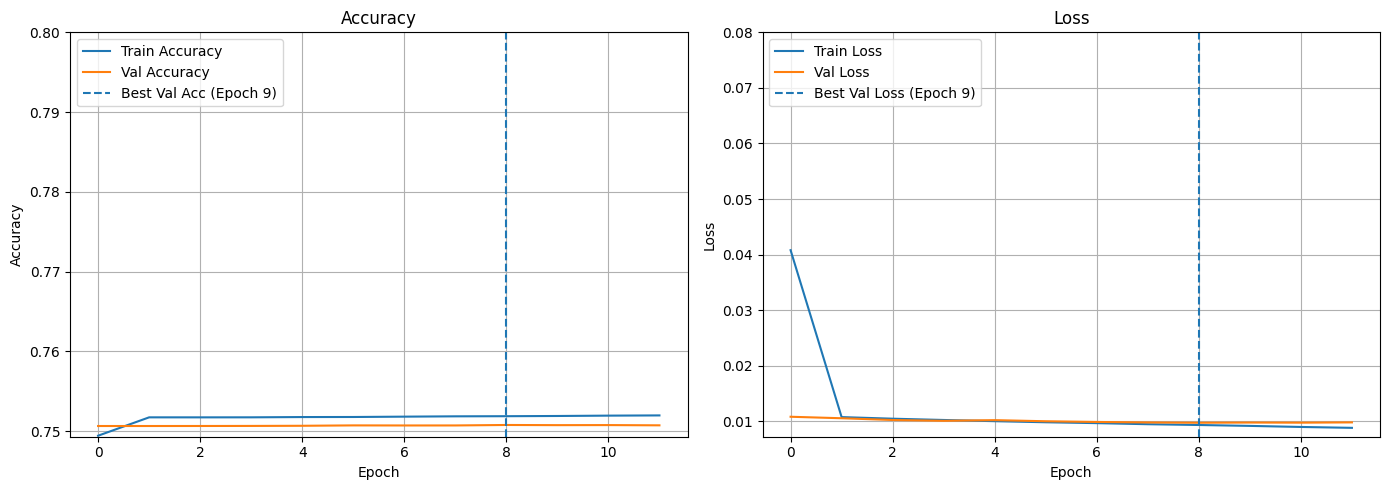

In [ ]:
import matplotlib.pyplot as plt

#Best epoch
best_val_loss_epoch = np.argmin(history.history['val_loss'])
best_val_acc_epoch  = np.argmax(history.history['val_accuracy'])

plt.figure(figsize=(14,5))


#Accurasy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')

plt.axvline(best_val_acc_epoch, linestyle='--',
            label=f'Best Val Acc (Epoch {best_val_acc_epoch+1})')

min_acc = min(history.history['val_accuracy'])
max_acc = max(history.history['accuracy'])

plt.yticks(np.arange(round(min_acc, 2), round(max_acc, 2)+0.05, 0.01))

plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

#Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')

plt.axvline(best_val_loss_epoch, linestyle='--',
            label=f'Best Val Loss (Epoch {best_val_loss_epoch+1})')

min_loss = min(history.history['val_loss'])
max_loss = max(history.history['loss'])

plt.yticks(np.arange(round(min_loss, 2), round(max_loss, 2)+0.05, 0.01))

plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()


plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, roc_auc_score

# Predict
y_pred = model.predict(X_test)

# Flatten + mask
mask = mask_test.flatten()

y_true = y_test.reshape(-1, 3)[mask]
y_pred = y_pred.reshape(-1, 3)[mask]

# Convert ke label
y_true_label = y_true.argmax(axis=1)
y_pred_label = y_pred.argmax(axis=1)

# Metrics
precision = precision_score(y_true_label, y_pred_label, average='macro')
recall = recall_score(y_true_label, y_pred_label, average='macro')
f1 = f1_score(y_true_label, y_pred_label, average='macro')

# AUC
auc = roc_auc_score(y_true, y_pred, multi_class='ovr')


print("===== FINAL METRICS =====")
print(f"Accuracy : {test_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")
print(f"Loss     : {test_loss:.4f}")

17/17 ━━━━━━━━━━━━━━━━━━━━ 151s 5s/step
===== FINAL METRICS =====
Accuracy : 0.8139
Precision: 0.4195
Recall   : 0.6177
F1 Score : 0.4313
AUC      : 0.9484
Loss     : 0.0120
